# Step 6 预测器P训练
---

## 1 Setup & Load Data

In [156]:
import numpy as np
import pandas as pd
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

DATA_DIR = Path("data")

with open(DATA_DIR / "splits.json") as f:
    splits = json.load(f)

train_start = pd.Timestamp(splits["train"]["start"])
train_end   = pd.Timestamp(splits["train"]["end"])
val_start   = pd.Timestamp(splits["val"]["start"])
val_end     = pd.Timestamp(splits["val"]["end"])

X_P_factors = ["CloseLoc", "SignedVolume_z252", "PriceVolCorr_z252", "Overnight",'Mom_20d','Mom_60d']

factors_full = pd.read_parquet(DATA_DIR / "spy_factors_step2.parquet")
residual = pd.read_parquet(DATA_DIR / "X_P_residual.parquet")
trend    = pd.read_parquet(DATA_DIR / "X_P_trend.parquet")
regime_fwd = pd.read_parquet(DATA_DIR / "regime_forward.parquet")

print("train:", train_start.date(), "->", train_end.date())
print("residual shape:", residual.shape)
print("trend shape:", trend.shape)
print("X_P factors:", X_P_factors)

train: 2017-01-05 -> 2023-04-25
residual shape: (2242, 6)
trend shape: (2242, 6)
X_P factors: ['CloseLoc', 'SignedVolume_z252', 'PriceVolCorr_z252', 'Overnight', 'Mom_20d', 'Mom_60d']


In [157]:
MINUTE_PATH = DATA_DIR / "spy_minute_clean.parquet"

minute_df = pd.read_parquet(MINUTE_PATH)



In [158]:
daily_close = minute_df["close"].resample("D").last().dropna()
daily_close.index = daily_close.index.normalize()
daily_close.name = "close"

print("daily_close shape:", daily_close.shape)
print("daily_close head:")
print(daily_close.head())
print("daily_close tail:")
print(daily_close.tail())
print("\nNaN count:", daily_close.isna().sum())

daily_close shape: (2745,)
daily_close head:
datetime
2015-01-02    205.410004
2015-01-05    201.800003
2015-01-06    199.820007
2015-01-07    202.339996
2015-01-08    205.919998
Name: close, dtype: float32
daily_close tail:
datetime
2025-12-24    689.885010
2025-12-26    690.250000
2025-12-29    687.840027
2025-12-30    686.929993
2025-12-31    681.840027
Name: close, dtype: float32

NaN count: 0


---
## 2 Apply Step 4 Locked Transforms to Raw X_P

In [159]:
def signed_log_scaled(x, scale):
    return np.sign(x) * np.log1p(np.abs(x) * scale)

X_P_raw = factors_full[X_P_factors].copy()
X_P_raw["Overnight"] = signed_log_scaled(X_P_raw["Overnight"], 1e2)

print(X_P_raw.describe())
print("\nNaN per column:")
print(X_P_raw.isna().sum())


          CloseLoc  SignedVolume_z252  PriceVolCorr_z252    Overnight  \
count  2745.000000        2242.000000        2242.000000  2744.000000   
mean      0.599923           0.010158           0.015964     0.029218   
std       0.317605           1.053790           1.022344     0.418625   
min       0.000000          -7.326289          -2.356870    -2.356692   
25%       0.327899          -0.481024          -0.727518    -0.208785   
50%       0.668469           0.059415          -0.101428     0.055686   
75%       0.893540           0.572949           0.624539     0.288247   
max       1.000000           8.783240           4.044139     1.848859   

           Mom_20d      Mom_60d  
count  2725.000000  2685.000000  
mean      0.008929     0.026525  
std       0.044273     0.066928  
min      -0.414220    -0.361973  
25%      -0.009070    -0.002403  
50%       0.015985     0.036937  
75%       0.033312     0.067813  
max       0.207063     0.336620  

NaN per column:
CloseLoc           

---
## 3 Construct Target r_{t+1} and Align All Inputs

In [160]:
log_close = np.log(daily_close)

r_next = log_close.shift(-1) - log_close
r_next.name = "r_next"

r_t = log_close - log_close.shift(1)
r_t.name = "r_t"

print("r_next describe:")
print(r_next.describe())
print("\nr_next lag-1 autocorr:", r_next.autocorr(lag=1))
print("r_t  lag-1 autocorr:", r_t.autocorr(lag=1))
print("\nr_next NaN count:", r_next.isna().sum())
print("r_t    NaN count:", r_t.isna().sum())

r_next describe:
count    2744.000000
mean        0.000437
std         0.010606
min        -0.063778
25%        -0.003792
50%         0.000640
75%         0.005908
max         0.090514
Name: r_next, dtype: float64

r_next lag-1 autocorr: -0.009296628777161071
r_t  lag-1 autocorr: -0.009296628777161071

r_next NaN count: 1
r_t    NaN count: 1


---
## 4 Build Train Feature Matrices (Main / Raw / Decomp) with Boundary Drop

In [161]:
BOUNDARY_DROP = 5

def slice_train(df):
    return df.loc[train_start:train_end]

X_P_train = slice_train(X_P_raw).copy()
trend_train = slice_train(trend).copy()
resid_train = slice_train(residual).copy()
y_train = slice_train(r_next).copy()
rt_train = slice_train(r_t).copy()
regime_train = slice_train(regime_fwd).copy()

X_P_train.columns = [f"{c}_xp" for c in X_P_train.columns]
trend_train.columns = [f"{c}_trend" for c in trend_train.columns]
resid_train.columns = [f"{c}_resid" for c in resid_train.columns]

main_df = pd.concat([X_P_train, trend_train, resid_train, y_train, rt_train, regime_train], axis=1)

main_df = main_df.iloc[BOUNDARY_DROP:-BOUNDARY_DROP]

main_df = main_df.dropna()

print("After boundary drop & NaN drop:", main_df.shape)
print("Date range:", main_df.index.min().date(), "->", main_df.index.max().date())

feat_main  = [c for c in main_df.columns if c.endswith(("_xp", "_trend", "_resid"))]
feat_raw   = [c for c in main_df.columns if c.endswith("_xp")]
feat_decomp = [c for c in main_df.columns if c.endswith(("_trend", "_resid"))]

print("\nMain features (12):", feat_main)
print("Raw features (4):", feat_raw)
print("Decomp features (8):", feat_decomp)

After boundary drop & NaN drop: (1559, 21)
Date range: 2017-01-12 -> 2023-04-18

Main features (12): ['CloseLoc_xp', 'SignedVolume_z252_xp', 'PriceVolCorr_z252_xp', 'Overnight_xp', 'Mom_20d_xp', 'Mom_60d_xp', 'CloseLoc_trend', 'SignedVolume_z252_trend', 'PriceVolCorr_z252_trend', 'Overnight_trend', 'Mom_60d_trend', 'Mom_20d_trend', 'CloseLoc_resid', 'SignedVolume_z252_resid', 'PriceVolCorr_z252_resid', 'Overnight_resid', 'Mom_60d_resid', 'Mom_20d_resid']
Raw features (4): ['CloseLoc_xp', 'SignedVolume_z252_xp', 'PriceVolCorr_z252_xp', 'Overnight_xp', 'Mom_20d_xp', 'Mom_60d_xp']
Decomp features (8): ['CloseLoc_trend', 'SignedVolume_z252_trend', 'PriceVolCorr_z252_trend', 'Overnight_trend', 'Mom_60d_trend', 'Mom_20d_trend', 'CloseLoc_resid', 'SignedVolume_z252_resid', 'PriceVolCorr_z252_resid', 'Overnight_resid', 'Mom_60d_resid', 'Mom_20d_resid']


---
## 5 Feature Correlation Heatmap (Diagnostic Before Training)

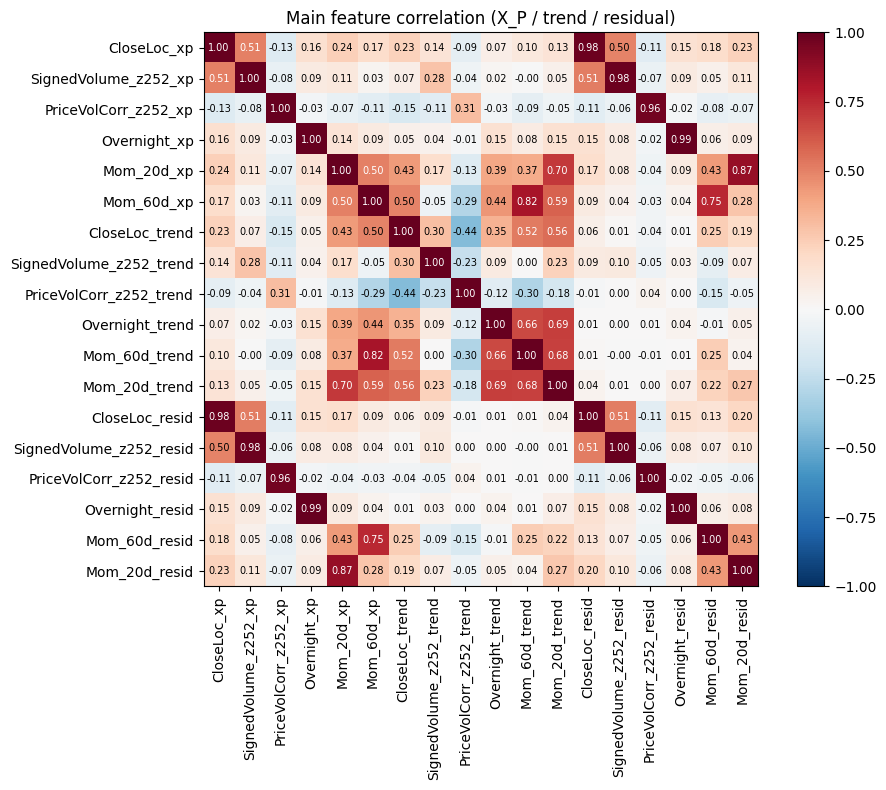


|rho| > 0.7 pairs:
  CloseLoc_xp <-> CloseLoc_resid: 0.984
  SignedVolume_z252_xp <-> SignedVolume_z252_resid: 0.982
  PriceVolCorr_z252_xp <-> PriceVolCorr_z252_resid: 0.963
  Overnight_xp <-> Overnight_resid: 0.993
  Mom_20d_xp <-> Mom_20d_trend: 0.704
  Mom_20d_xp <-> Mom_20d_resid: 0.874
  Mom_60d_xp <-> Mom_60d_trend: 0.825
  Mom_60d_xp <-> Mom_60d_resid: 0.753


In [162]:
corr_main = main_df[feat_main].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_main.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_main)))
ax.set_yticks(range(len(feat_main)))
ax.set_xticklabels(feat_main, rotation=90)
ax.set_yticklabels(feat_main)
for i in range(len(feat_main)):
    for j in range(len(feat_main)):
        ax.text(j, i, f"{corr_main.values[i,j]:.2f}", ha="center", va="center",
                fontsize=7, color="black" if abs(corr_main.values[i,j]) < 0.5 else "white")
plt.colorbar(im, ax=ax)
plt.title("Main feature correlation (X_P / trend / residual)")
plt.tight_layout()
plt.show()

print("\n|rho| > 0.7 pairs:")
for i, c1 in enumerate(feat_main):
    for j, c2 in enumerate(feat_main):
        if i < j and abs(corr_main.iloc[i, j]) > 0.7:
            print(f"  {c1} <-> {c2}: {corr_main.iloc[i, j]:.3f}")

正常情况下，L1滤波应该xp和trend相关性低，xp和resid相关性高。但这里动量因子trend和resid都与原始因子相关性很高，这说明L1没有把原始信号有效分解为两个独立的成分。这是因为动量本身就是一个平滑后的慢变序列，没有什么高频的噪声可以被L1剥离。

---
## 6  Standardize Features and Define CV — Residual-only vs Raw

In [163]:
y = main_df["r_next"].values
rt_arr = main_df["r_t"].values
regimes = main_df["regime"].values
dates = main_df.index

feat_resid = [c for c in main_df.columns if c.endswith("_resid")]
feat_raw   = [c for c in main_df.columns if c.endswith("_xp")]

X_resid_raw = main_df[feat_resid].values
X_raw_raw   = main_df[feat_raw].values

scaler_resid = StandardScaler().fit(X_resid_raw)
scaler_raw   = StandardScaler().fit(X_raw_raw)

X_resid = scaler_resid.transform(X_resid_raw)
X_raw   = scaler_raw.transform(X_raw_raw)

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

ALPHA_GRID = np.logspace(-3, 2, 20)

print("y shape:", y.shape)
print("X_resid shape:", X_resid.shape, "  features:", feat_resid)
print("X_raw   shape:", X_raw.shape,   "  features:", feat_raw)
print("\nCV fold sizes:")
for i, (tr, te) in enumerate(tscv.split(y)):
    print(f"  fold {i}: train={len(tr)}, test={len(te)}")

y shape: (1559,)
X_resid shape: (1559, 6)   features: ['CloseLoc_resid', 'SignedVolume_z252_resid', 'PriceVolCorr_z252_resid', 'Overnight_resid', 'Mom_60d_resid', 'Mom_20d_resid']
X_raw   shape: (1559, 6)   features: ['CloseLoc_xp', 'SignedVolume_z252_xp', 'PriceVolCorr_z252_xp', 'Overnight_xp', 'Mom_20d_xp', 'Mom_60d_xp']

CV fold sizes:
  fold 0: train=264, test=259
  fold 1: train=523, test=259
  fold 2: train=782, test=259
  fold 3: train=1041, test=259
  fold 4: train=1300, test=259


# 7按regime切分训练数据

In [164]:
REGIME_LABELS = {0: "r0", 1: "r1"}
K_FINAL = 2

print("=== Regime sample counts (K=2) ===")
regime_masks = {}
for r in range(K_FINAL):
    regime_masks[r] = regimes == r
    n = regime_masks[r].sum()
    print(f"  r{r}: {n} samples ({n / len(regimes) * 100:.1f}%)")

=== Regime sample counts (K=2) ===
  r0: 737 samples (47.3%)
  r1: 822 samples (52.7%)


In [165]:
def rank_ic(y_true, y_pred):
    return stats.spearmanr(y_true, y_pred).correlation

def cv_ridge(X, y, alphas, cv):
    results = []
    for a in alphas:
        ic_folds, mse_folds = [], []
        for tr, te in cv.split(X):
            mdl = Ridge(alpha=a).fit(X[tr], y[tr])
            yp = mdl.predict(X[te])
            ic_folds.append(rank_ic(y[te], yp))
            mse_folds.append(np.mean((y[te] - yp) ** 2))
        results.append({
            "alpha": a,
            "ic_mean": np.mean(ic_folds),
            "ic_std":  np.std(ic_folds),
            "mse_mean": np.mean(mse_folds),
            "ic_folds": ic_folds,
        })
    return pd.DataFrame(results)

cv_resid_by_regime = {}
cv_raw_by_regime   = {}

for r in range(K_FINAL):
    mask = regime_masks[r]
    X_resid_r = X_resid[mask]
    X_raw_r   = X_raw[mask]
    y_r       = y[mask]
    n_r       = mask.sum()

    n_splits_r = min(N_SPLITS, max(2, n_r // 50))
    tscv_r = TimeSeriesSplit(n_splits=n_splits_r)

    cv_resid_by_regime[r] = cv_ridge(X_resid_r, y_r, ALPHA_GRID, tscv_r)
    cv_raw_by_regime[r]   = cv_ridge(X_raw_r,   y_r, ALPHA_GRID, tscv_r)

    print(f"\n=== Regime r{r} — Residual CV ===")
    print(cv_resid_by_regime[r][["alpha", "ic_mean", "ic_std", "mse_mean"]].to_string(index=False))
    print(f"\n=== Regime r{r} — Raw CV ===")
    print(cv_raw_by_regime[r][["alpha", "ic_mean", "ic_std", "mse_mean"]].to_string(index=False))
 



=== Regime r0 — Residual CV ===
     alpha  ic_mean   ic_std  mse_mean
  0.001000 0.138549 0.054765  0.000246
  0.001833 0.138549 0.054765  0.000246
  0.003360 0.138549 0.054765  0.000246
  0.006158 0.138549 0.054765  0.000246
  0.011288 0.138549 0.054765  0.000246
  0.020691 0.138549 0.054765  0.000246
  0.037927 0.138549 0.054765  0.000246
  0.069519 0.138592 0.054779  0.000246
  0.127427 0.138592 0.054779  0.000246
  0.233572 0.138592 0.054779  0.000246
  0.428133 0.138562 0.054769  0.000246
  0.784760 0.138577 0.054764  0.000246
  1.438450 0.138968 0.054600  0.000246
  2.636651 0.138520 0.054382  0.000246
  4.832930 0.138101 0.054110  0.000245
  8.858668 0.137840 0.054181  0.000245
 16.237767 0.137250 0.054160  0.000244
 29.763514 0.139115 0.052500  0.000243
 54.555948 0.139519 0.051925  0.000242
100.000000 0.142218 0.053147  0.000241

=== Regime r0 — Raw CV ===
     alpha  ic_mean   ic_std  mse_mean
  0.001000 0.039986 0.046954  0.000257
  0.001833 0.039986 0.046954  0.000257
  0

---
## 8 CV Curves Plot (Visual Inspection Before α Lock-in)

R0 regime


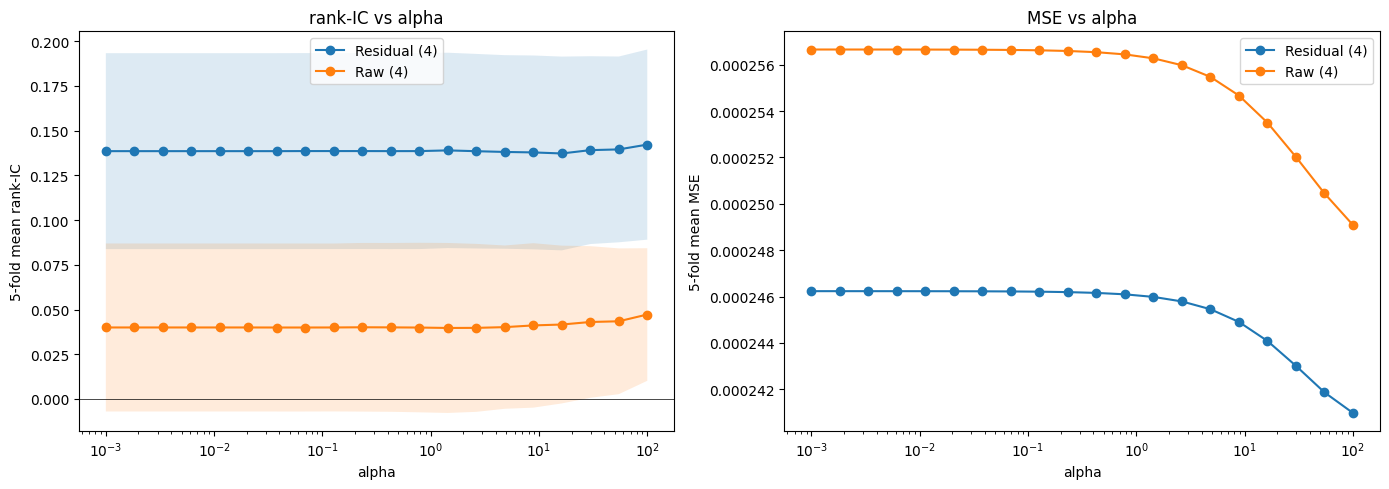


Max rank-IC per model:
  Residual  : alpha=100.0000, ic_mean=0.1422, ic_std=0.0531
  Raw       : alpha=100.0000, ic_mean=0.0472, ic_std=0.0370

Residual vs Raw IC delta at each alpha:
  alpha=  0.0010  delta_IC = +0.0986
  alpha=  0.0018  delta_IC = +0.0986
  alpha=  0.0034  delta_IC = +0.0986
  alpha=  0.0062  delta_IC = +0.0986
  alpha=  0.0113  delta_IC = +0.0986
  alpha=  0.0207  delta_IC = +0.0986
  alpha=  0.0379  delta_IC = +0.0986
  alpha=  0.0695  delta_IC = +0.0986
  alpha=  0.1274  delta_IC = +0.0986
  alpha=  0.2336  delta_IC = +0.0985
  alpha=  0.4281  delta_IC = +0.0985
  alpha=  0.7848  delta_IC = +0.0986
  alpha=  1.4384  delta_IC = +0.0993
  alpha=  2.6367  delta_IC = +0.0988
  alpha=  4.8329  delta_IC = +0.0979
  alpha=  8.8587  delta_IC = +0.0967
  alpha= 16.2378  delta_IC = +0.0956
  alpha= 29.7635  delta_IC = +0.0961
  alpha= 54.5559  delta_IC = +0.0961
  alpha=100.0000  delta_IC = +0.0950


In [166]:
print("="*50)
print("R0 regime")
print("="*50)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for df, label in [(cv_resid_by_regime[0], "Residual (4)"), (cv_raw_by_regime[0], "Raw (4)")]:
    axes[0].plot(df["alpha"], df["ic_mean"], marker="o", label=label)
    axes[0].fill_between(df["alpha"],
                         df["ic_mean"] - df["ic_std"],
                         df["ic_mean"] + df["ic_std"], alpha=0.15)
    axes[1].plot(df["alpha"], df["mse_mean"], marker="o", label=label)

axes[0].set_xscale("log"); axes[0].set_xlabel("alpha"); axes[0].set_ylabel("5-fold mean rank-IC")
axes[0].axhline(0, color="black", lw=0.5); axes[0].legend(); axes[0].set_title("rank-IC vs alpha")
axes[1].set_xscale("log"); axes[1].set_xlabel("alpha"); axes[1].set_ylabel("5-fold mean MSE")
axes[1].legend(); axes[1].set_title("MSE vs alpha")
plt.tight_layout(); plt.show()

print("\nMax rank-IC per model:")
for df, label in [(cv_resid_by_regime[0], "Residual"), (cv_raw_by_regime[0], "Raw")]:
    idx = df["ic_mean"].idxmax()
    print(f"  {label:10s}: alpha={df.loc[idx,'alpha']:.4f}, "
          f"ic_mean={df.loc[idx,'ic_mean']:.4f}, ic_std={df.loc[idx,'ic_std']:.4f}")

print("\nResidual vs Raw IC delta at each alpha:")
delta = cv_resid_by_regime[0]["ic_mean"].values - cv_raw_by_regime[0]["ic_mean"].values
for a, d in zip(cv_resid_by_regime[0]["alpha"], delta):
    print(f"  alpha={a:8.4f}  delta_IC = {d:+.4f}")

R1 regime


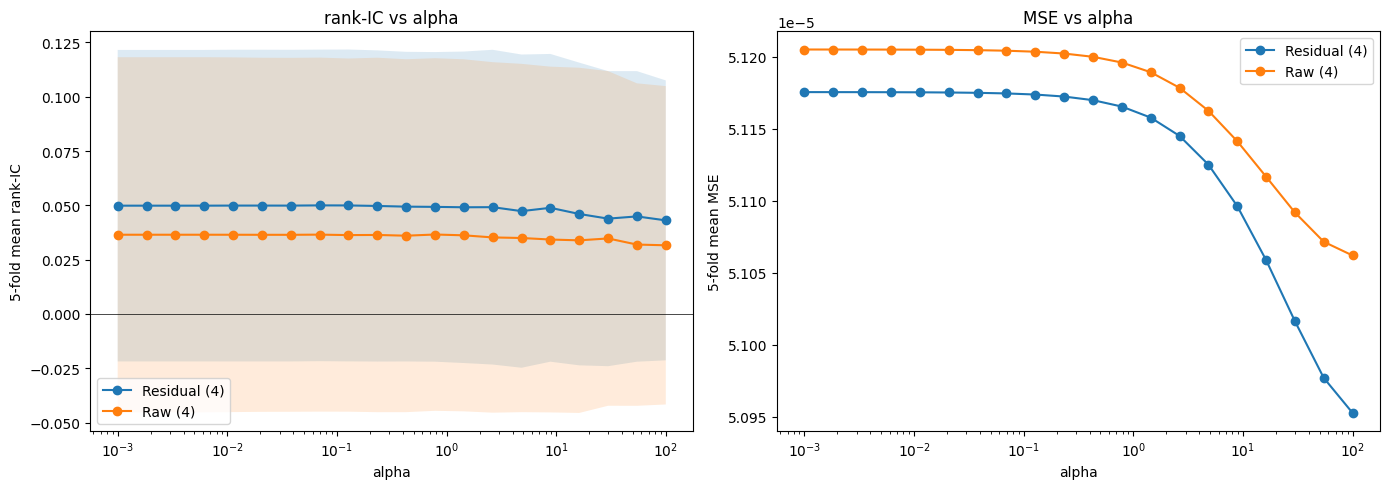


Max rank-IC per model:
  Residual  : alpha=0.0695, ic_mean=0.0500, ic_std=0.0717
  Raw       : alpha=0.7848, ic_mean=0.0366, ic_std=0.0812

Residual vs Raw IC delta at each alpha:
  alpha=  0.0010  delta_IC = +0.0134
  alpha=  0.0018  delta_IC = +0.0134
  alpha=  0.0034  delta_IC = +0.0134
  alpha=  0.0062  delta_IC = +0.0134
  alpha=  0.0113  delta_IC = +0.0134
  alpha=  0.0207  delta_IC = +0.0135
  alpha=  0.0379  delta_IC = +0.0134
  alpha=  0.0695  delta_IC = +0.0135
  alpha=  0.1274  delta_IC = +0.0137
  alpha=  0.2336  delta_IC = +0.0133
  alpha=  0.4281  delta_IC = +0.0134
  alpha=  0.7848  delta_IC = +0.0127
  alpha=  1.4384  delta_IC = +0.0129
  alpha=  2.6367  delta_IC = +0.0139
  alpha=  4.8329  delta_IC = +0.0124
  alpha=  8.8587  delta_IC = +0.0146
  alpha= 16.2378  delta_IC = +0.0121
  alpha= 29.7635  delta_IC = +0.0091
  alpha= 54.5559  delta_IC = +0.0130
  alpha=100.0000  delta_IC = +0.0115


In [167]:
print("="*50)
print("R1 regime")
print("="*50)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for df, label in [(cv_resid_by_regime[1], "Residual (4)"), (cv_raw_by_regime[1], "Raw (4)")]:
    axes[0].plot(df["alpha"], df["ic_mean"], marker="o", label=label)
    axes[0].fill_between(df["alpha"],
                         df["ic_mean"] - df["ic_std"],
                         df["ic_mean"] + df["ic_std"], alpha=0.15)
    axes[1].plot(df["alpha"], df["mse_mean"], marker="o", label=label)

axes[0].set_xscale("log"); axes[0].set_xlabel("alpha"); axes[0].set_ylabel("5-fold mean rank-IC")
axes[0].axhline(0, color="black", lw=0.5); axes[0].legend(); axes[0].set_title("rank-IC vs alpha")
axes[1].set_xscale("log"); axes[1].set_xlabel("alpha"); axes[1].set_ylabel("5-fold mean MSE")
axes[1].legend(); axes[1].set_title("MSE vs alpha")
plt.tight_layout(); plt.show()

print("\nMax rank-IC per model:")
for df, label in [(cv_resid_by_regime[1], "Residual"), (cv_raw_by_regime[1], "Raw")]:
    idx = df["ic_mean"].idxmax()
    print(f"  {label:10s}: alpha={df.loc[idx,'alpha']:.4f}, "
          f"ic_mean={df.loc[idx,'ic_mean']:.4f}, ic_std={df.loc[idx,'ic_std']:.4f}")

print("\nResidual vs Raw IC delta at each alpha:")
delta = cv_resid_by_regime[1]["ic_mean"].values - cv_raw_by_regime[1]["ic_mean"].values
for a, d in zip(cv_resid_by_regime[1]["alpha"], delta):
    print(f"  alpha={a:8.4f}  delta_IC = {d:+.4f}")

对r0 regime，选取α=1.438 作为平坦区代表值,既避免选边界值的过拟合嫌疑,也保留了适度正则化对共线特征的稳定作用。
对r1 regime, 选取α=0.7848，因为其IC最大。

In [168]:
regime_alpha_locked={}
regime_alpha_locked[0]=1.4384
regime_alpha_locked[1]=0.0695

In [169]:
import statsmodels.api as sm
print("\n=== Regime-conditional final Ridge fit ===")
print(f"{'Regime':<8} {'alpha':>8} {'train_IC':>10} {'HAC_t':>8} {'N':>6}")
print("-" * 45)
 
regime_models  = {}   # {r: fitted Ridge model}
regime_signals = {}   # {r: predicted signal（regime 子集长度）}
regime_diag_cm = {}   # {r: 诊断指标 dict}
 
for r in range(K_FINAL):
    mask    = regime_masks[r]
    X_r     = X_resid[mask]      # 使用全局 scaler_resid 已标准化的数据
    y_r     = y[mask]
    alpha_r = regime_alpha_locked[r]
 
    mdl_r = Ridge(alpha=alpha_r).fit(X_r, y_r)
    sig_r = mdl_r.predict(X_r)
 
    ic_r      = stats.spearmanr(y_r, sig_r).correlation
    pearson_r = np.corrcoef(y_r, sig_r)[0, 1]
 
    X_const_r = sm.add_constant(sig_r)
    ols_r     = sm.OLS(y_r, X_const_r).fit(
        cov_type="HAC", cov_kwds={"maxlags": min(10, mask.sum() // 10)}
    )
    nw_t_r     = ols_r.tvalues[1]
    nw_slope_r = ols_r.params[1]
 
    regime_models[r]  = mdl_r
    regime_signals[r] = sig_r
    regime_diag_cm[r] = {
        "alpha":      alpha_r,
        "n_samples":  int(mask.sum()),
        "train_ic":   float(ic_r),
        "pearson_ic": float(pearson_r),
        "hac_t":      float(nw_t_r),
        "slope":      float(nw_slope_r),
        "r_squared":  float(ols_r.rsquared),
        "coef": {name: float(c)
                 for name, c in zip(feat_resid, mdl_r.coef_)},
        "intercept":  float(mdl_r.intercept_),
    }
 
    print(f"  r{r:<5} {alpha_r:>8.4f} {ic_r:>10.4f} {nw_t_r:>8.3f} {mask.sum():>6}")
 


=== Regime-conditional final Ridge fit ===
Regime      alpha   train_IC    HAC_t      N
---------------------------------------------
  r0       1.4384     0.1690    5.545    737
  r1       0.0695     0.0877    2.286    822


In [170]:
signal_regime_train = np.full(len(y), np.nan)
for r in range(K_FINAL):
    signal_regime_train[regime_masks[r]] = regime_signals[r]
 
signal_regime_series = pd.Series(
    signal_regime_train, index=dates, name="signal_regime_t"
)
 
# 整体诊断（与 Cell 23 single Ridge 对标）
overall_ic_regime      = stats.spearmanr(y, signal_regime_train).correlation
overall_pearson_regime = np.corrcoef(y, signal_regime_train)[0, 1]
X_const_all = sm.add_constant(signal_regime_train)
ols_all     = sm.OLS(y, X_const_all).fit(
    cov_type="HAC", cov_kwds={"maxlags": 10}
)
 
print(f"\n=== Regime-conditional model: overall train diagnostics ===")
print(f"  Rank-IC          : {overall_ic_regime:+.4f}  ")
print(f"  Pearson IC       : {overall_pearson_regime:+.4f}")
print(f"  HAC t-stat lag10 : {ols_all.tvalues[1]:+.4f}  ")
print(f"  R-squared        : {ols_all.rsquared:.6f}")
 


=== Regime-conditional model: overall train diagnostics ===
  Rank-IC          : +0.1168  
  Pearson IC       : +0.2086
  HAC t-stat lag10 : +5.9479  
  R-squared        : 0.043534


In [171]:
print(f"\n=== Regime-conditional coefficients (standardized space) ===")
header = f"{'Factor':<35}  {'r0':>14}  {'r1':>14} "
print(header)
print("-" * len(header))
 
for i, name in enumerate(feat_resid):
    c_r0  = regime_diag_cm[0]["coef"][name]
    c_r1  = regime_diag_cm[1]["coef"][name]
    print(f"{name:<35}  {c_r0:>+14.6f}  {c_r1:>+14.6f}  ")


=== Regime-conditional coefficients (standardized space) ===
Factor                                           r0              r1 
--------------------------------------------------------------------
CloseLoc_resid                            +0.000078       +0.000034  
SignedVolume_z252_resid                   -0.001164       -0.000235  
PriceVolCorr_z252_resid                   -0.000269       -0.000175  
Overnight_resid                           +0.000921       -0.000815  
Mom_60d_resid                             -0.001930       -0.000798  
Mom_20d_resid                             -0.000828       -0.000409  


In [172]:
signal_regime_series.to_frame().to_parquet(
    DATA_DIR / "P_signal_train.parquet"
)
 
with open(DATA_DIR / "P_model.pkl", "wb") as f:
    pickle.dump({
        "regime_models":   regime_models,     # {0: Ridge, 1: Ridge}
        "scaler_resid":    scaler_resid,      # 全局 scaler，与单模型一致
        "feature_names":   feat_resid,
        "alpha_locked":    regime_alpha_locked,
        "regime_labels":   REGIME_LABELS,
        "K_FINAL":         K_FINAL,
        "feature_set":     "residual_only_4dim",
    }, f)
 
with open(DATA_DIR / "P_regime_diagnostics.json", "w") as f:
    json.dump({
        "K_FINAL": K_FINAL,
        "overall": {
            "train_rank_ic":    float(overall_ic_regime),
            "hac_t_stat_lag10": float(ols_all.tvalues[1]),
            "r_squared":        float(ols_all.rsquared),
            
        },
        "per_regime": {
            str(r): regime_diag_cm[r] for r in range(K_FINAL)
        },
    }, f, indent=2)
 
print("\nSaved:")
print("  data/P_signal_regime_train.parquet")
print("  data/P_regime_models.pkl")
print("  data/P_regime_diagnostics.json")
 


Saved:
  data/P_signal_regime_train.parquet
  data/P_regime_models.pkl
  data/P_regime_diagnostics.json
